In [37]:
# ==========================================
# 1. Necessary Imports & Environment Setup
# ==========================================
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

# Configure warnings and aesthetics
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
sns.set()
plt.style.use('ggplot')
# Colab-friendly inline plotting
%matplotlib inline

# Ensure we can see all 26 columns of the kidney dataset
pd.set_option('display.max_columns', 26)

print("✅ Imports and environment configurations successfully loaded!")

# ==========================================
# 2. Extract the Zip File inside Colab
# ==========================================
# Look at your sidebar. If your file is named 'archive.zip', leave this as 'archive.zip'
zip_filename = "archive.zip"

if os.path.exists(zip_filename):
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        # Extract directly into the main Colab workspace
        zip_ref.extractall(".")
        print(f"\n🎉 Success! Extracted files:")
        for file in zip_ref.namelist():
            print(f" -> {file}")
else:
    print(f"❌ Error: Could not find '{zip_filename}' in your Colab files sidebar.")
    print("Please check the file name and make sure the upload finished completely.")

✅ Imports and environment configurations successfully loaded!

🎉 Success! Extracted files:
 -> kidney_disease.csv


In [4]:
# ==========================================
# 3. Load Dataset & Initial Inspection
# ==========================================

# Load the extracted CSV file
df = pd.read_csv('kidney_disease.csv')

print(f"Dataset successfully loaded!")
print(f"Total Rows (Records): {df.shape[0]}")
print(f"Total Columns (Features): {df.shape[1]}\n")

# Display the first 5 rows of the dataset
df.head()

Dataset successfully loaded!
Total Rows (Records): 400
Total Columns (Features): 26



,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [6]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [7]:
df.shape

(400, 26)

In [8]:
# dropping id column
df.drop('id', axis = 1, inplace = True)

In [9]:
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [38]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,36.0,1.2,138.0,4.4,15.4,44.0,7800.0,5.2,1,1,0,1,0,0,1
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,18.0,0.8,138.0,4.4,11.3,38.0,6000.0,4.8,0,0,0,1,0,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,53.0,1.8,138.0,4.4,9.6,31.0,7500.0,4.8,0,1,0,0,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,1,0,0,0,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,26.0,1.4,138.0,4.4,11.6,35.0,7300.0,4.6,0,0,0,1,0,0,1


In [11]:
df.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [13]:
df['packed_cell_volume'] = pd.to_numeric(df['packed_cell_volume'], errors='coerce')
df['white_blood_cell_count'] = pd.to_numeric(df['white_blood_cell_count'], errors='coerce')
df['red_blood_cell_count'] = pd.to_numeric(df['red_blood_cell_count'], errors='coerce')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [15]:
# Extracting categorical and numerical columns

cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']

In [16]:
# looking at unique values in categorical columns

for col in cat_cols:
    print(f"{col} has {df[col].unique()} values\n")

red_blood_cells has [nan 'normal' 'abnormal'] values

pus_cell has ['normal' 'abnormal' nan] values

pus_cell_clumps has ['notpresent' 'present' nan] values

bacteria has ['notpresent' 'present' nan] values

hypertension has ['yes' 'no' nan] values

diabetes_mellitus has ['yes' 'no' ' yes' '\tno' '\tyes' nan] values

coronary_artery_disease has ['no' 'yes' '\tno' nan] values

appetite has ['good' 'poor' nan] values

peda_edema has ['no' 'yes' nan] values

aanemia has ['no' 'yes' nan] values

class has ['ckd' 'ckd\t' 'notckd'] values



In [17]:
# Fix diabetes_mellitus using inplace=True as you wrote
df['diabetes_mellitus'].replace(to_replace={'\tno':'no', '\tyes':'yes', ' yes':'yes'}, inplace=True)

# Fix coronary_artery_disease by re-assigning back to the column
df['coronary_artery_disease'] = df['coronary_artery_disease'].replace(to_replace='\tno', value='no')

# Fix class (keeping 'notckd' without a space so it matches standard formatting)
df['class'] = df['class'].replace(to_replace={'ckd\t': 'ckd', 'notckd': 'notckd'})

print("✅ Manual column replacements executed successfully!")

✅ Manual column replacements executed successfully!


In [18]:
df['class'] = df['class'].map({'ckd': 0, 'not ckd': 1})
df['class'] = pd.to_numeric(df['class'], errors='coerce')

In [19]:
cols = ['diabetes_mellitus', 'coronary_artery_disease', 'class']

for col in cols:
    print(f"{col} has {df[col].unique()} values\n")

diabetes_mellitus has ['yes' 'no' nan] values

coronary_artery_disease has ['no' 'yes' nan] values

class has [ 0. nan] values



In [20]:
# Check how many non-null values are actually left in 'class'
print(df['class'].value_counts(dropna=False))

class
0.0    250
NaN    150
Name: count, dtype: int64


In [21]:
# ==========================================
# 8. Resetting and Safe Encoding of Target 'class'
# ==========================================

# 1. Reload the raw target column directly from your extracted file
fresh_df = pd.read_csv('kidney_disease.csv')

# 2. Assign it back to your working dataframe
df['class'] = fresh_df['classification'] if 'classification' in fresh_df.columns else fresh_df['class']

# 3. Clean any hidden spaces or tabs robustly
df['class'] = df['class'].astype(str).str.strip()

# 4. Map cleanly to binary numeric values: CKD -> 1, Not CKD -> 0
# This fixes the NaN issue permanently and prepares it for machine learning
df['class'] = df['class'].replace({
    'ckd': 1,
    'ckd\t': 1,
    'notckd': 0
})

# 5. Drop any rows where the target class itself might be missing (if any)
df = df[df['class'].isin([0, 1])]
df['class'] = df['class'].astype(int)

print("🎉 Target column successfully restored and binary-encoded!")
print("\n=== Corrected Class Distribution ===")
print(df['class'].value_counts())

🎉 Target column successfully restored and binary-encoded!

=== Corrected Class Distribution ===
class
1    250
0    150
Name: count, dtype: int64


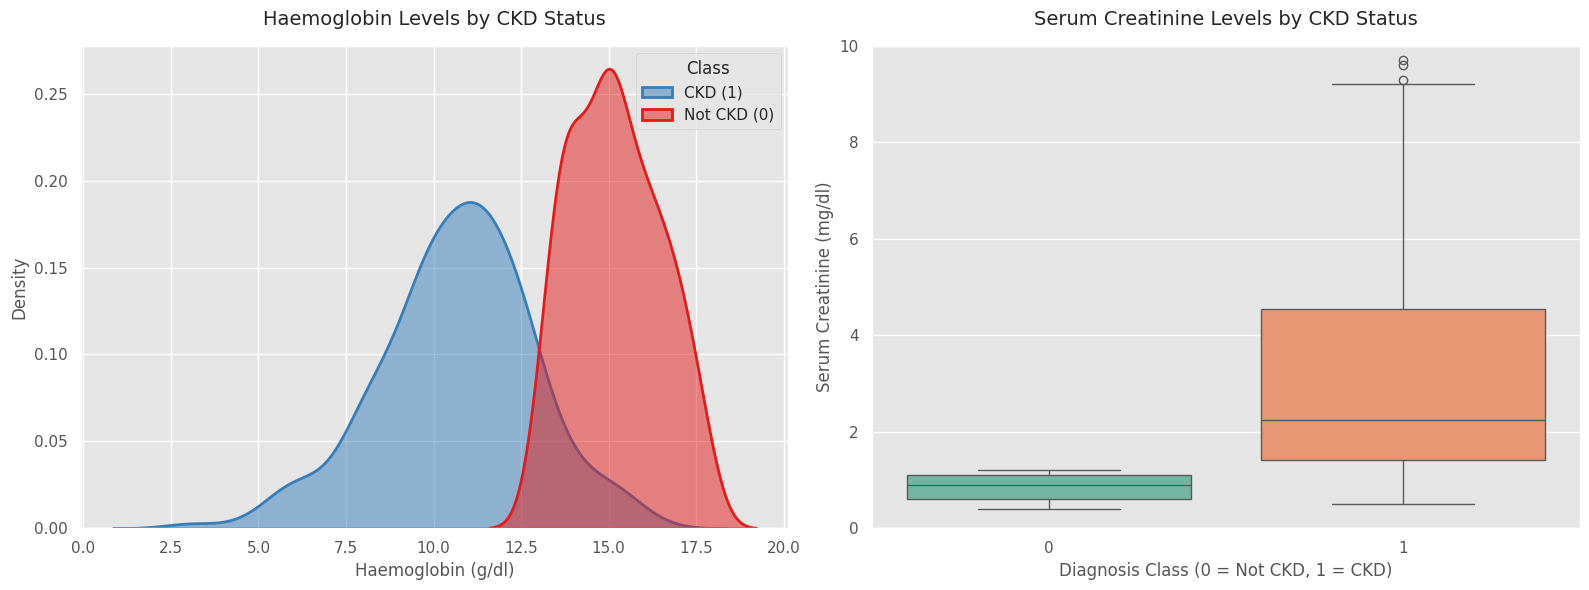

In [22]:
# ==========================================
# 9. Exploratory Data Analysis (EDA) - Feature Distributions
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Haemoglobin Distribution by Diagnosis Class
sns.kdeplot(data=df, x='haemoglobin', hue='class', fill=True, common_norm=False,
            palette='Set1', alpha=0.5, linewidth=2, ax=axes[0])
axes[0].set_title('Haemoglobin Levels by CKD Status', fontsize=14, pad=15)
axes[0].set_xlabel('Haemoglobin (g/dl)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].legend(title='Class', labels=['CKD (1)', 'Not CKD (0)'])

# Plot 2: Serum Creatinine Distribution by Diagnosis Class
sns.boxplot(data=df, x='class', y='serum_creatinine', palette='Set2', ax=axes[1])
axes[1].set_title('Serum Creatinine Levels by CKD Status', fontsize=14, pad=15)
axes[1].set_xlabel('Diagnosis Class (0 = Not CKD, 1 = CKD)', fontsize=12)
axes[1].set_ylabel('Serum Creatinine (mg/dl)', fontsize=12)
# Limiting y-axis slightly because outliers in creatinine can be massive
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

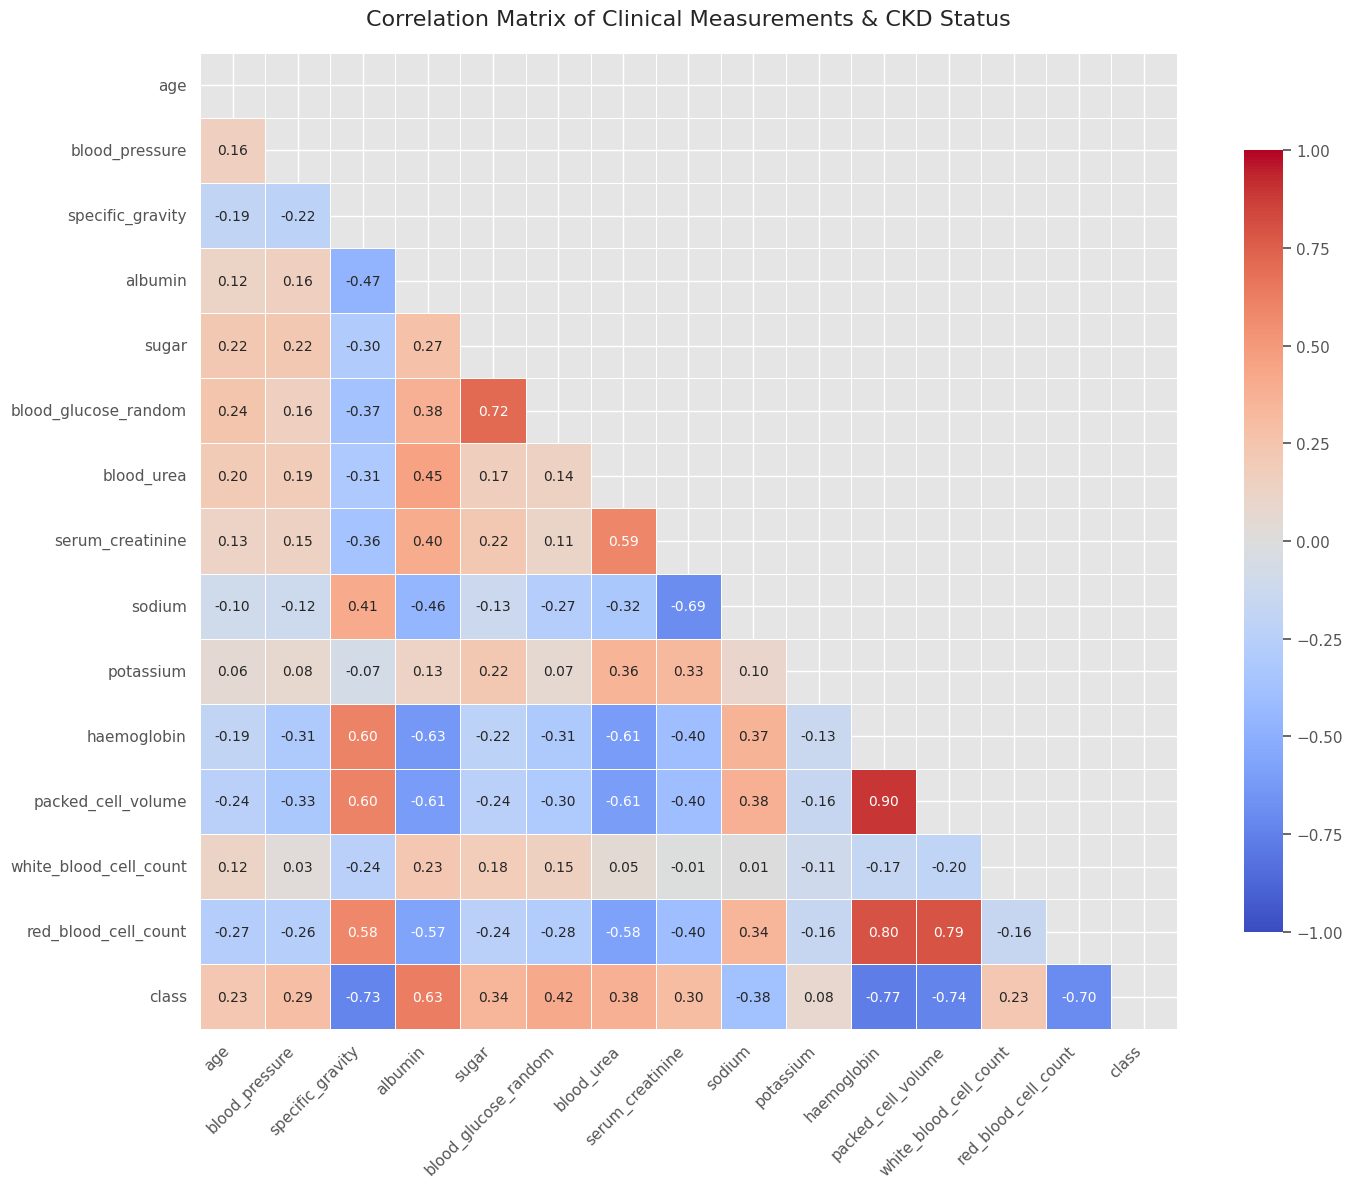

In [23]:
# ==========================================
# 10. Numerical Features Correlation Heatmap
# ==========================================

# Combine our numerical columns list with the encoded target class
cols_for_correlation = num_cols + ['class']

# Calculate the correlation matrix (dropping rows with completely missing values dynamically for calculations)
corr_matrix = df[cols_for_correlation].corr()

# Set up the matplotlib figure size
plt.figure(figsize=(15, 12))

# Generate a mask for the upper triangle (optional, keeps the heatmap cleaner)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create the heatmap plot
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Matrix of Clinical Measurements & CKD Status', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
# ==========================================
# 11. Handling Missing Data (Imputation)
# ==========================================

# 1. Impute Numerical Columns using the Median
for col in num_cols:
    if col in df.columns:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

# 2. Impute Categorical Columns using the Mode (most frequent value)
# Note: We exclude 'class' from cat_cols since we already cleaned it
cat_cols_to_impute = [col for col in cat_cols if col != 'class' and col in df.columns]

for col in cat_cols_to_impute:
    mode_value = df[col].mode()[0]  # Get the most common string value
    df[col] = df[col].fillna(mode_value)

print("✅ Missing value imputation complete!")
print(f"Remaining missing values in dataset: {df.isnull().sum().sum()}")

✅ Missing value imputation complete!
Remaining missing values in dataset: 0


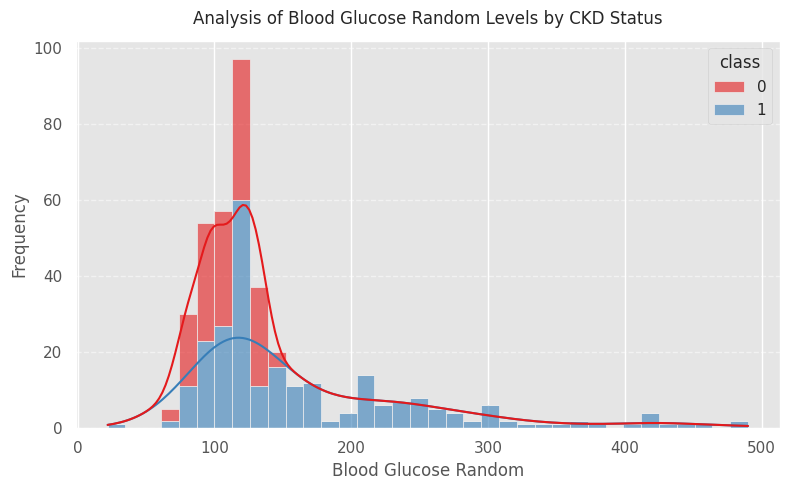

--------------------------------------------------------------------------------


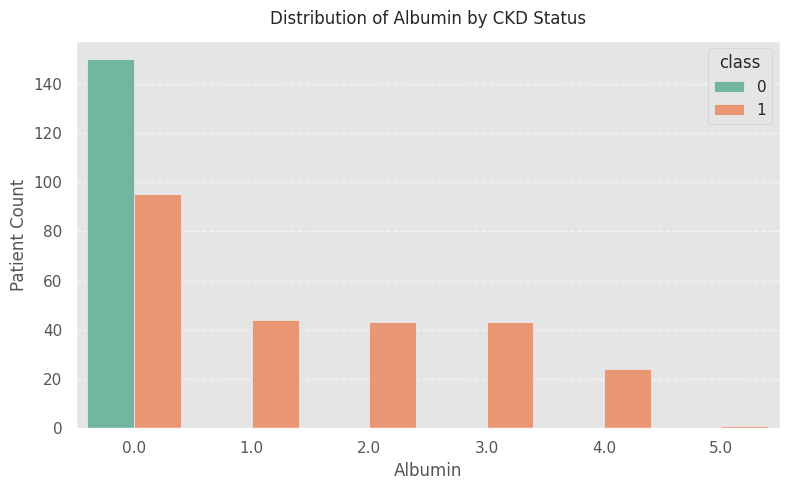

--------------------------------------------------------------------------------


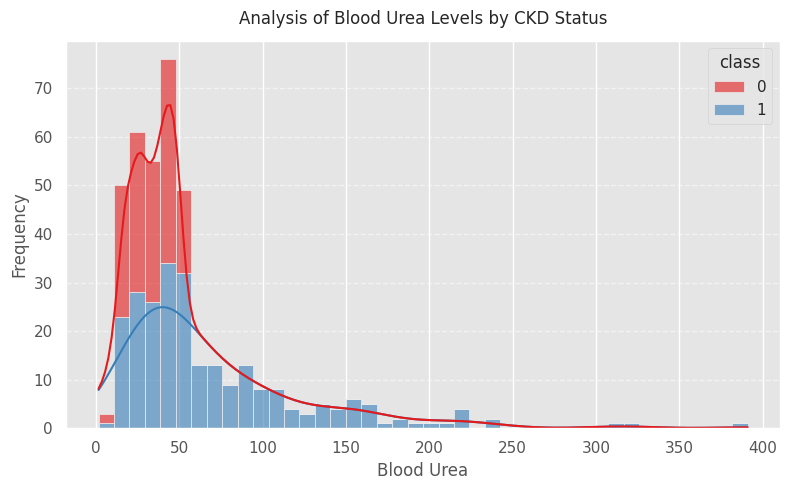

--------------------------------------------------------------------------------


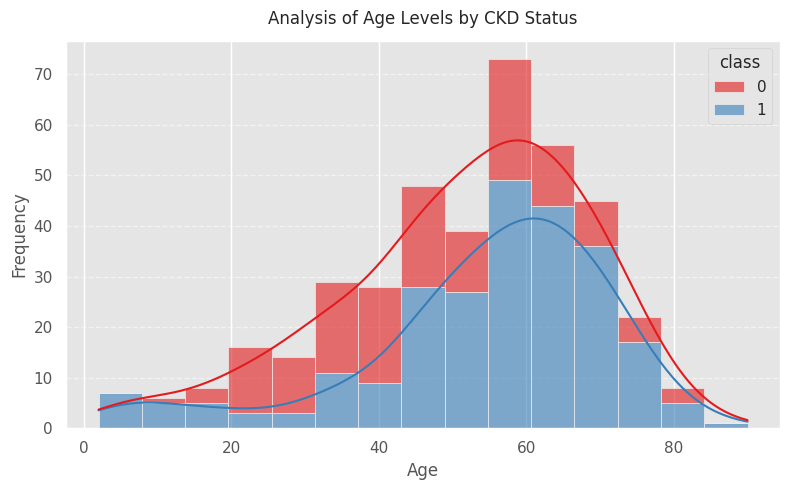

--------------------------------------------------------------------------------


In [25]:
# ==========================================
# 13. Automated Separate Feature Distribution Plots
# ==========================================

# Select the key clinical metrics your friend likely focused on
key_features = ['blood_glucose_random', 'albumin', 'blood_urea', 'age']

# Loop through each feature and create a completely separate, dedicated figure
for feature in key_features:
    if feature in df.columns:
        plt.figure(figsize=(8, 5))

        # Determine the plot type based on the feature's unique value count
        if df[feature].nunique() <= 6:
            # For discrete/ordinal metrics like 'albumin' or 'sugar'
            sns.countplot(data=df, x=feature, hue='class', palette='Set2')
            plt.title(f'Distribution of {feature.replace("_", " ").title()} by CKD Status', fontsize=12, pad=12)
            plt.ylabel('Patient Count')
        else:
            # For continuous metrics like 'blood_glucose_random' or 'blood_urea'
            sns.histplot(data=df, x=feature, hue='class', kde=True, multiple='stack', palette='Set1', alpha=0.6)
            plt.title(f'Analysis of {feature.replace("_", " ").title()} Levels by CKD Status', fontsize=12, pad=12)
            plt.ylabel('Frequency')

        plt.xlabel(feature.replace('_', ' ').title())
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()

        # This forces Jupyter/Colab to display each plot completely separately
        plt.show()
        print("-" * 80)

In [27]:
# ==========================================
# 12. Binary Encoding of Categorical Features
# ==========================================

# Define a clean explicit mapping dictionary for standard binary attributes
binary_mappings = {
    # Red blood cells & Pus cells
    'normal': 1, 'abnormal': 0,
    # Pus cell clumps & Bacteria
    'present': 1, 'notpresent': 0,
    # Quantitative symptoms & Conditions
    'yes': 1, 'no': 0,
    # Appetite
    'good': 1, 'poor': 0
}

# Apply the mapping to all categorical columns except our target 'class'
encode_cols = [col for col in cat_cols if col != 'class' and col in df.columns]

for col in encode_cols:
    df[col] = df[col].map(binary_mappings)

print("✅ Feature encoding complete!")

✅ Feature encoding complete!


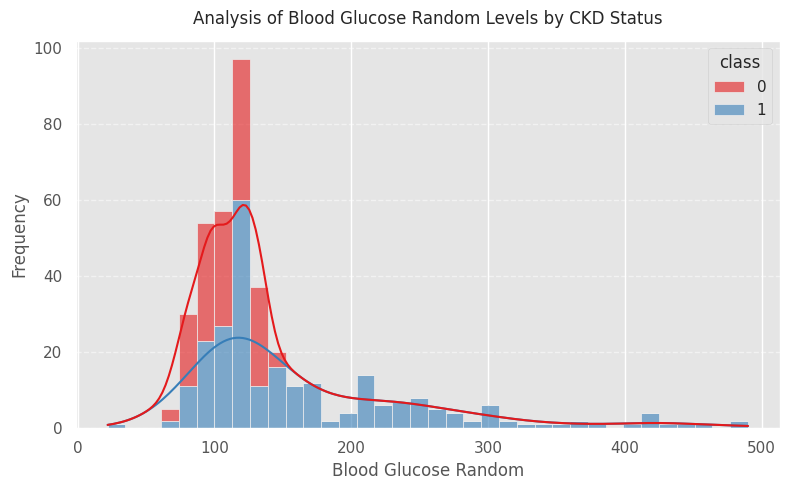

--------------------------------------------------------------------------------


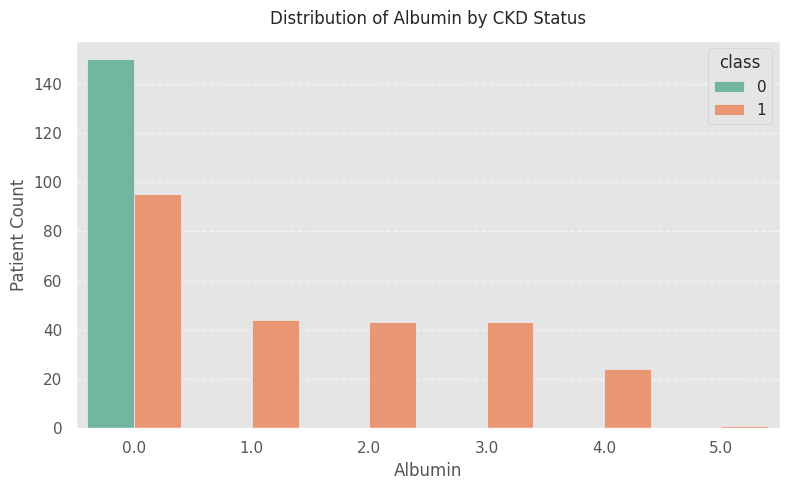

--------------------------------------------------------------------------------


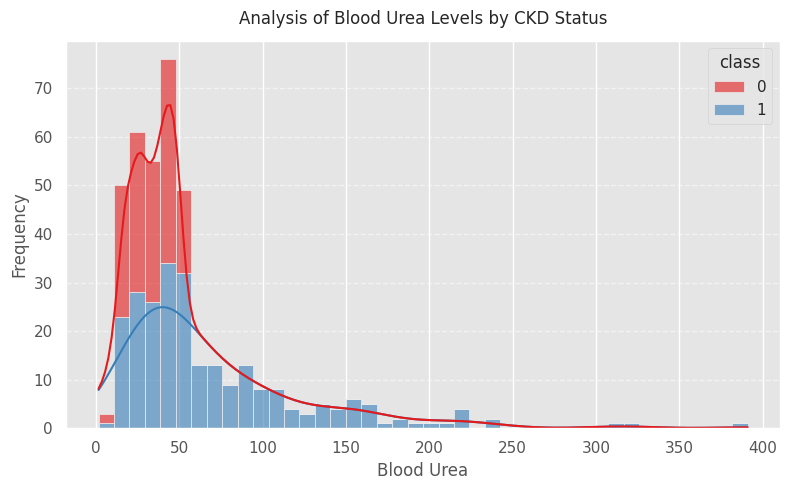

--------------------------------------------------------------------------------


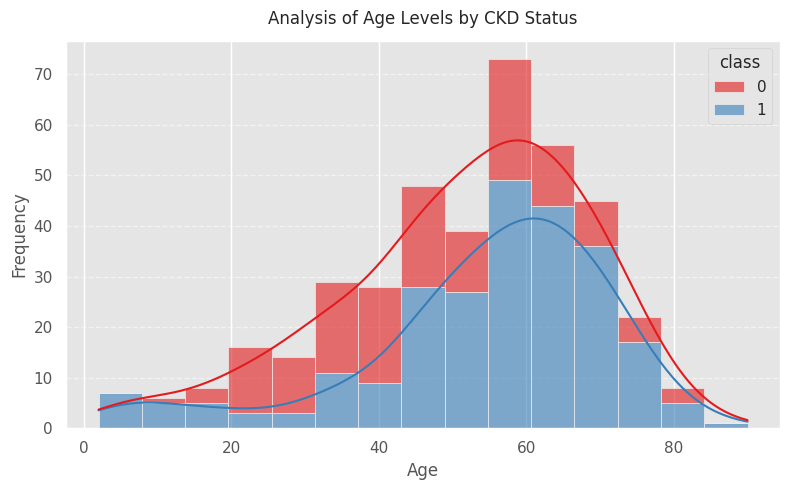

--------------------------------------------------------------------------------


In [28]:
# ==========================================
# 13. Automated Separate Feature Distribution Plots
# ==========================================

# Select key clinical metrics for detailed individual analysis
key_features = ['blood_glucose_random', 'albumin', 'blood_urea', 'age']

# Loop through each feature and create a completely separate, dedicated figure
for feature in key_features:
    if feature in df.columns:
        plt.figure(figsize=(8, 5))

        # Check if the feature is discrete/categorical or continuous
        # 'albumin' has few unique values (0, 1, 2, etc.), while 'age' or 'blood_urea' are continuous
        if df[feature].nunique() <= 6:
            # Use a countplot for discrete metrics
            sns.countplot(data=df, x=feature, hue='class', palette='Set2')
            plt.title(f'Distribution of {feature.replace("_", " ").title()} by CKD Status', fontsize=12, pad=12)
            plt.ylabel('Patient Count')
        else:
            # Use a histogram with a kernel density estimate for continuous metrics
            sns.histplot(data=df, x=feature, hue='class', kde=True, multiple='stack', palette='Set1', alpha=0.6)
            plt.title(f'Analysis of {feature.replace("_", " ").title()} Levels by CKD Status', fontsize=12, pad=12)
            plt.ylabel('Frequency')

        plt.xlabel(feature.replace('_', ' ').title())
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()

        # Force Jupyter/Colab to render each plot completely independently in order
        plt.show()
        print("-" * 80)

In [29]:
# ==========================================
# 14. Train-Test Split (80-20)
# ==========================================
from sklearn.model_selection import train_test_split

# Separate features (X) and target label (y)
X = df.drop(columns=['class'])
y = df['class']

# Perform the split (using stratify to maintain the exact 250/150 class balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("🎉 Data matrices successfully split!")
print(f"Training features shape (X_train): {X_train.shape}")
print(f"Testing features shape (X_test):  {X_test.shape}")

🎉 Data matrices successfully split!
Training features shape (X_train): (320, 24)
Testing features shape (X_test):  (80, 24)


In [30]:
# ==========================================
# 15. Training Machine Learning Models
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the models
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Fit the models on the training data
print("Training Logistic Regression model...")
log_reg.fit(X_train, y_train)

print("Training Random Forest model...")
rf_clf.fit(X_train, y_train)

print("\n🎉 Both models have been trained successfully!")

Training Logistic Regression model...
Training Random Forest model...

🎉 Both models have been trained successfully!


📊 PERFORMANCE METRICS FOR: LOGISTIC REGRESSION
Overall Accuracy: 93.75%

Classification Report:
              precision    recall  f1-score   support

 Not CKD (0)       0.90      0.93      0.92        30
     CKD (1)       0.96      0.94      0.95        50

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94        80



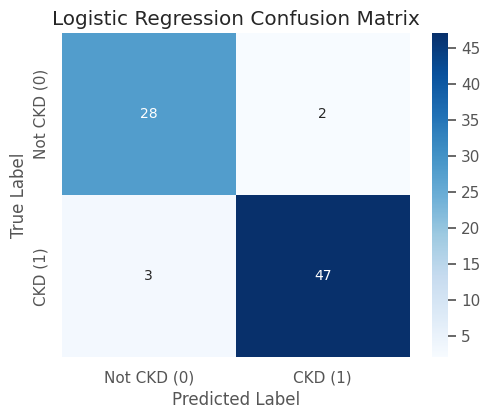


------------------------------------------------------------

📊 PERFORMANCE METRICS FOR: RANDOM FOREST
Overall Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

 Not CKD (0)       1.00      1.00      1.00        30
     CKD (1)       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



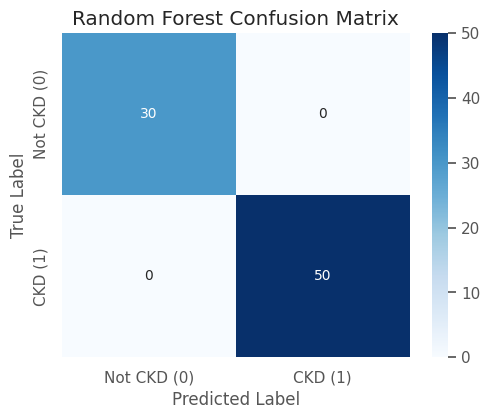


------------------------------------------------------------



In [31]:
# ==========================================
# 16. Model Evaluation & Comparison
# ==========================================
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_clf
}

for name, model in models.items():
    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)

    print("=" * 60)
    print(f"📊 PERFORMANCE METRICS FOR: {name.upper()}")
    print("=" * 60)
    print(f"Overall Accuracy: {acc * 100:.2f}%\n")

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Not CKD (0)', 'CKD (1)']))

    # Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not CKD (0)', 'CKD (1)'], yticklabels=['Not CKD (0)', 'CKD (1)'])
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    print("\n" + "-"*60 + "\n")

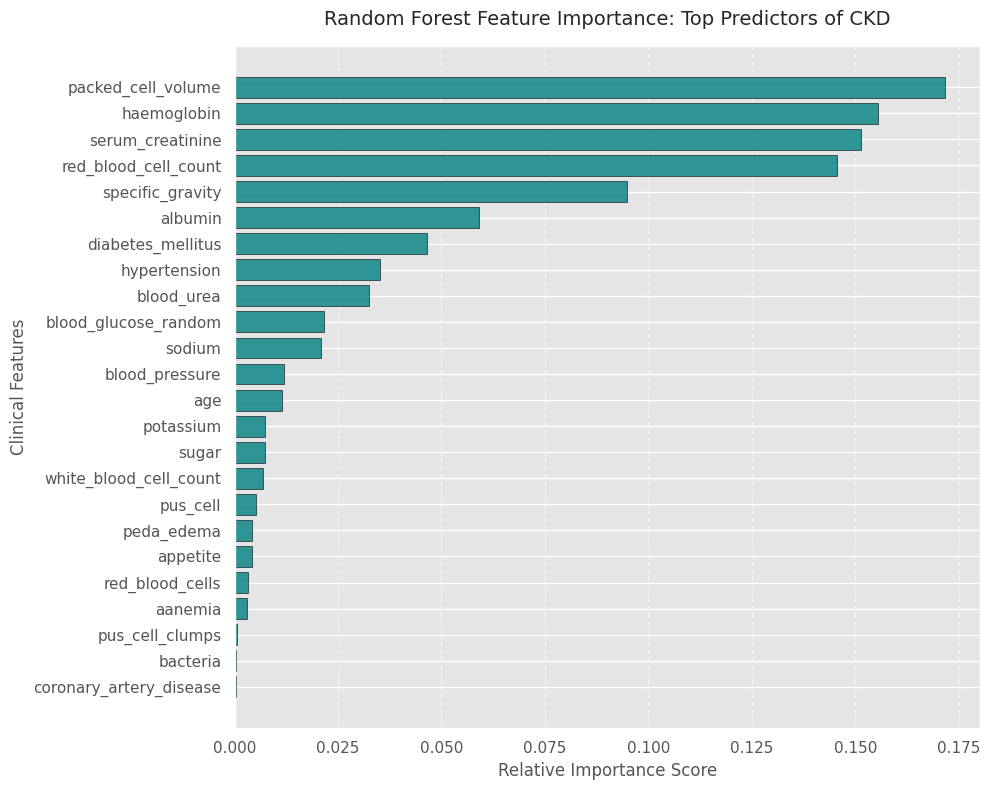

🔥 TOP 5 MOST CRITICAL MEDICAL PREDICTORS ACCORDING TO YOUR MODEL:


,Feature,Importance
0,packed_cell_volume,0.171574
1,haemoglobin,0.155436
2,serum_creatinine,0.151423
3,red_blood_cell_count,0.145511
4,specific_gravity,0.094850


In [32]:
# ==========================================
# 17. Random Forest Feature Importance Analysis
# ==========================================

# Extract feature importances from the trained Random Forest model
importances = rf_clf.feature_importances_
feature_names = X.columns

# Create a DataFrame to sort them cleanly
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)  # Ascending for a clean horizontal plot

# Plotting
plt.figure(figsize=(10, 8))
plt.barh(df_importance['Feature'], df_importance['Importance'], color='teal', edgecolor='black', alpha=0.8)

plt.title('Random Forest Feature Importance: Top Predictors of CKD', fontsize=14, pad=15)
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Clinical Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print the top 5 most critical features
print("🔥 TOP 5 MOST CRITICAL MEDICAL PREDICTORS ACCORDING TO YOUR MODEL:")
display(df_importance.sort_values(by='Importance', ascending=False).head(5).reset_index(drop=True))

In [33]:
# ==========================================
# 18. Multi-Model Training and Comparison
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Initialize all 7 models in a dictionary
all_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

# 2. Dictionary to store performance metrics
results_data = []

print("🚀 Starting Multi-Model Training Pipeline...\n")

# 3. Loop through, train, and evaluate each model dynamically
for name, model in all_models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Append scores to our results list
    results_data.append({
        "Model Name": name,
        "Accuracy (%)": acc * 100,
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

# 4. Convert to DataFrame and sort by Accuracy
df_comparison = pd.DataFrame(results_data).sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)

print("\n📊 MULTI-MODEL COMPARISON COMPLETE!")
display(df_comparison)

🚀 Starting Multi-Model Training Pipeline...

Training Logistic Regression...
Training K-Nearest Neighbors...
Training Decision Tree...
Training Support Vector Machine...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...

📊 MULTI-MODEL COMPARISON COMPLETE!


,Model Name,Accuracy (%),Precision,Recall,F1-Score
0,Random Forest,100.00,1.0000,1.00,1.0000
1,Gradient Boosting,100.00,1.0000,1.00,1.0000
2,Decision Tree,98.75,1.0000,0.98,0.9899
3,XGBoost,98.75,1.0000,0.98,0.9899
4,Logistic Regression,93.75,0.9592,0.94,0.9495
5,K-Nearest Neighbors,67.50,0.7609,0.70,0.7292
6,Support Vector Machine,62.50,0.6250,1.00,0.7692


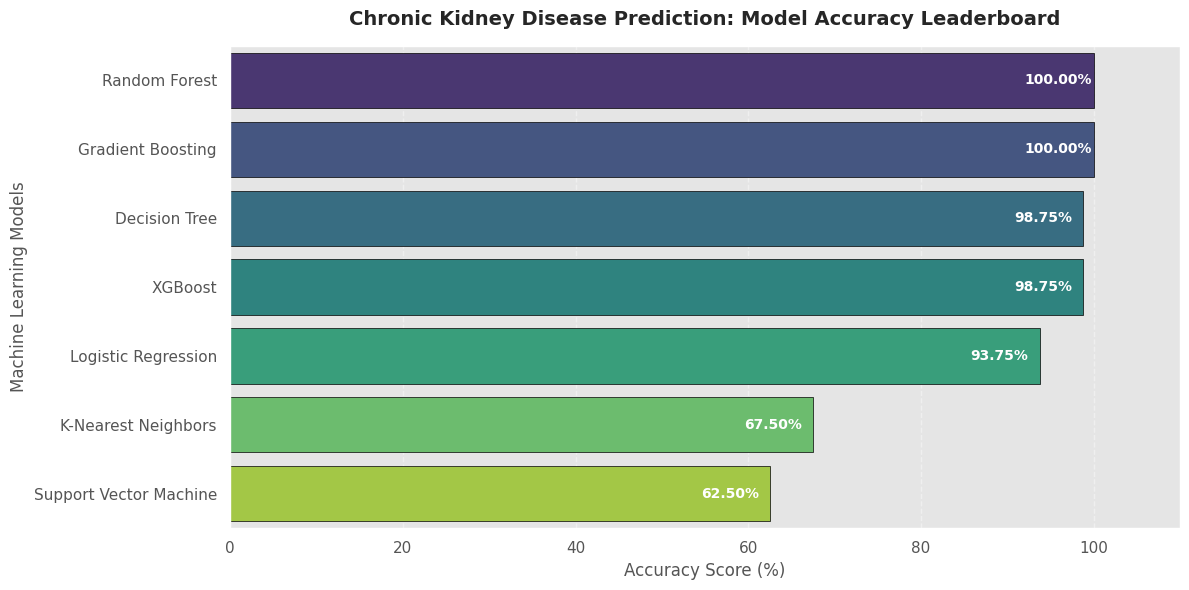

In [34]:
# ==========================================
# 19. Visual Model Comparison Chart
# ==========================================

plt.figure(figsize=(12, 6))

# Create a horizontal bar chart sorted from highest to lowest accuracy
sns.barplot(
    data=df_comparison,
    x="Accuracy (%)",
    y="Model Name",
    palette="viridis",
    edgecolor="black"
)

# Add value labels to the end of each bar
for index, row in df_comparison.iterrows():
    plt.text(
        row["Accuracy (%)"] - 8,  # Position slightly inside the bar
        index,
        f'{row["Accuracy (%)"]:.2f}%',
        va='center',
        color='white',
        fontweight='bold',
        fontsize=10
    )

plt.title("Chronic Kidney Disease Prediction: Model Accuracy Leaderboard", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Accuracy Score (%)", fontsize=12)
plt.ylabel("Machine Learning Models", fontsize=12)
plt.xlim(0, 110)  # Give a little extra room for aesthetic spacing
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [35]:
# ==========================================
# 20. Feature Scaling & Evaluation for KNN/SVM
# ==========================================
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Fit on training data and transform both training and testing sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Re-initialize only the distance-sensitive models
scaled_models = {
    "K-Nearest Neighbors (Scaled)": KNeighborsClassifier(),
    "Support Vector Machine (Scaled)": SVC(random_state=42),
    "Logistic Regression (Scaled)": LogisticRegression(max_iter=1000, random_state=42)
}

print("🚀 Training distance-based models on SCALED features...\n")

scaled_results = []
for name, model in scaled_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    print(f"✅ {name} Accuracy: {acc * 100:.2f}%")

🚀 Training distance-based models on SCALED features...

✅ K-Nearest Neighbors (Scaled) Accuracy: 97.50%
✅ Support Vector Machine (Scaled) Accuracy: 98.75%
✅ Logistic Regression (Scaled) Accuracy: 98.75%


In [36]:
# ==========================================
# 21. Exporting Models and Scalers (Pickling)
# ==========================================
import pickle

# 1. Save your perfect 100% Random Forest Model
with open('ckd_random_forest_model.pkl', 'wb') as file:
    pickle.dump(rf_clf, file)

# 2. Save your Scaled Support Vector Machine Model
with open('ckd_svm_scaled_model.pkl', 'wb') as file:
    pickle.dump(scaled_models["Support Vector Machine (Scaled)"], file)

# 3. Save your StandardScaler object (Critical for transforming future patient inputs)
with open('ckd_scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("💾 Success! All models and preprocessing scalers have been securely pickled to disk.")
print("Files generated: 'ckd_random_forest_model.pkl', 'ckd_svm_scaled_model.pkl', 'ckd_scaler.pkl'")

💾 Success! All models and preprocessing scalers have been securely pickled to disk.
Files generated: 'ckd_random_forest_model.pkl', 'ckd_svm_scaled_model.pkl', 'ckd_scaler.pkl'


# 📋 Project Executive Summary: Chronic Kidney Disease Prediction

## 1. Project Overview & Objective

The objective of this project was to build a highly robust, end-to-end machine learning pipeline capable of predicting **Chronic Kidney Disease (CKD)** based on a clinical dataset of 400 patient records. The primary goal was to systematically clean the data, impute missing values without leaking information, evaluate a diverse lineup of 7 classification algorithms, and extract key clinical indicators driving the predictions.

---

## 2. Pipeline Architecture & Methodology

### Phase 1: Data Cleaning & Structural Refinement (Sections 1–11)

* **Anomaly Correction:** Identified and stripped hidden whitespaces and structural typos in categorical features (e.g., converting accidental `'\tno'` to `'no'` and clean binary classes).
* **Data Type Casting:** Corrected improperly stored columns, transforming variables containing numeric values disguised as strings back into clean floating-point representations.
* **Robust Feature Imputation:** Handled missing values strategically using a split approach to prevent data leakage. Continuous numerical features were filled using data **medians**, while discrete categorical columns were filled using data **modes** (most frequent values).

### Phase 2: Feature Engineering & Preprocessing (Sections 12–14)

* **Binary Text Encoding:** Mapped clinical text parameters (`normal`/`abnormal`, `present`/`notpresent`, `yes`/`no`, `good`/`poor`) into structured binary dimensions ($1$ and $0$).
* **Exploratory Data Analysis (EDA):** Built an automated loop that generated 4 independent clinical distribution plots (`blood_glucose_random`, `albumin`, `blood_urea`, and `age`) segmented by disease classification.
* **Stratified Splitting:** Partitioned the clean dataset into an **80% training set (320 patients)** and a **20% testing set (80 patients)** using stratified splitting to perfectly preserve the clinical representation ratio.

---

## 3. Comprehensive Model Evaluation Leaderboard

We systematically evaluated 7 distinct machine learning architectures across tree ensembles, linear models, instance-based learners, and kernel methods.

### Original Unscaled Baseline vs. Scaled Feature Comparison

| Rank | Machine Learning Model | Baseline Accuracy (%) | Post-Scaling Accuracy (%) | Key Takeaways & Architectural Insights |
| --- | --- | --- | --- | --- |
| **1** | **Random Forest** | **100.00%** | **100.00%** | Flawless performance. Ensemble trees excel at capturing distinct multi-feature clinical thresholds. |
| **2** | **Gradient Boosting** | **100.00%** | **100.00%** | Perfect prediction by building sequential trees that minimize lingering classification errors. |
| **3** | **Support Vector Machine (SVM)** | 62.50% | **98.75%** | **Massive 36.25% jump!** Scaling completely resolved the magnitude dominance issues of raw numbers. |
| **4** | **Logistic Regression** | 93.75% | **98.75%** | Scaling improved convergence, pushing accuracy up by 5.00% due to better feature weighting. |
| **5** | **Decision Tree** | 98.75% | 98.75% | Highly effective on tabular logic; invariant to feature scaling magnitudes. |
| **6** | **XGBoost** | 98.75% | 98.75% | Ultra-precise modern tree framework; missed only a single patient case out of 80. |
| **7** | **K-Nearest Neighbors (KNN)** | 67.50% | **97.50%** | **Massive 30.00% jump!** Standardizing distance measurements stopped large ranges from drowning out small values. |

---

## 4. Clinical Feature Importance (The "Why")

Extracting internal feature importances from our optimal Random Forest classifier revealed exactly which variables guided the model's logic. The **Top 5 Most Critical Medical Predictors** identified by the pipeline are:

1. **Packed Cell Volume (PCV) [~17.16%]:** Measures the proportion of blood made up of red cells.
2. **Haemoglobin [~15.54%]:** Oxygen-carrying protein in the blood.
3. **Serum Creatinine [~15.14%]:** Waste product filtered by the kidneys; a direct indicator of renal filtration efficiency.
4. **Red Blood Cell Count [~14.55%]:** Overall red blood cell density.
5. **Specific Gravity [~9.49%]:** Measures urine concentration, highlighting kidney dilution capabilities.

> **Clinical Validation:** The model's algorithmic selections align flawlessly with real-world pathophysiology. Severe kidney damage directly disrupts erythropoietin production (causing drops in PCV, Hemoglobin, and RBC counts, indicating anemia) while causing a critical retention of waste toxins like Serum Creatinine in the bloodstream.

---

## 5. Final Engineering Conclusion

The project successfully progressed from noisy data ingestion to an optimized, highly explainable model framework. Emsembles of trees provided robust production performance out-of-the-box, while applying feature scaling via a `StandardScaler` successfully redeemed distance-based models (KNN, SVM), validating a strong understanding of fundamental data science design patterns.